In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

Hi there,

I've been stuck on a problem for quite a while and I was wondering if anyone had any ideas. 

I believe this is due to a vanishing gradient where the smaller mean variables have much lower gradients and so are essentially ignored by the model. 

I think the root cause of this might be the behavior of the negative binomial distribution 

In [192]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan


class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [273]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale = 1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(
            num_var=self.n_var, 
            hidden_dims=[1000, 1000, 1000], 
            outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)]
        )
        self.classifier = antipode.train_utils.SimpleFFNN(
            in_dim=self.n_latent, 
            hidden_dims=[1000, 1000, 1000], 
            out_dim=self.n_components
        )
        self.temperature = 0.1
        
    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            batch_plate = pyro.plate('batch', data.shape[0], dim=-2)
            latent_plate = pyro.plate('latent_plate', self.n_latent, dim=-1)
            
            l = data.sum(-1).unsqueeze(-1) + 1.
            
            with batch_plate:
                locs = pyro.param('locs', 0.2 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.2 * torch.randn(self.n_latent, self.n_var, device=device))
                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 25 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                total_counts = total_counts + 0.1
                taxon_probs = pyro.sample('taxon_probs', dist.Dirichlet(torch.ones(data.shape[0], self.n_components, device=device), validate_args=True))
                taxon = pyro.sample("taxon", antipode.model_distributions.SafeAndRelaxedOneHotCategorical(
                    temperature=self.temperature, 
                    probs=taxon_probs, 
                    validate_args=True
                ))
                
            latent = pyro.sample('latent', dist.Normal(taxon @ locs, taxon @ scales + 1e-4).to_event(2))
            out_mu = latent @ transform_matrix + taxon @ intercept

            logits = torch.nn.functional.log_softmax(out_mu, dim=-1) - total_counts.log() + l.log()
            out_dist = dist.NegativeBinomial(total_count=total_counts, logits=logits, validate_args=False)
            nb_scales = (out_dist.log_prob((logits + 1).exp()) - out_dist.log_prob(logits.exp())).abs()
            nb_scales = self.n_var * nb_scales / nb_scales.sum()
            print(nb_scales.mean(0).shape)
            
            with batch_plate, pyro.plate('var', size=self.n_var, dim=-1), poutine.scale(scale=nb_scales.mean(0)):
                recon = pyro.sample('obs', out_dist, obs=data)

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            batch_plate = pyro.plate('batch', data.shape[0], dim=-2)
            latent_plate = pyro.plate('latent_plate', self.n_latent, dim=-1)
            
            locs_mu, locs_std = self.encoder(data)
            latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std + 1e-4).to_event(2))
                
            with batch_plate:
                taxon_probs = pyro.sample('taxon_probs', dist.Delta(antipode.model_functions.safe_softmax(self.classifier(latent), dim=-1)).to_event(1))
                taxon = pyro.sample("taxon", antipode.model_distributions.SafeAndRelaxedOneHotCategorical(
                    temperature=self.temperature, 
                    probs=taxon_probs, 
                    validate_args=True
                ))


In [274]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 14*torch.rand(n_var)-7.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
#data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [275]:
(data>0).sum(0)

tensor([   40,   773,   518, 25410,     2,     1,   401,  1202,   961,   135,
         6445,     0, 10516,     0,    37,     1, 24361,     1,     1, 21563,
            5, 10336,    10,  4070,  5255,     9, 15614, 26158,  6296,   689,
           12,  7529,    27,     0, 20255,   100,  1447, 22596,  4598,  4569,
         2326, 13563,   113, 15868,    25,   635, 21127, 11237,     3,   324,
         5038,     4,   814,   205,    10,     3,   851,  4948,   733,    12,
           56, 24006, 13403, 17335, 25230, 13454,    79,  5347, 26211, 18409,
        16274,  5843,  2338,    76,    34, 10543,   121,   258,  3268,  2542,
          478,    20,  5483, 23578, 14678,   142, 24892,    22,  1340,   264,
           56,    13, 17757,     8, 23329, 18695,  3122,   858,  5303,    11,
          210,     3,   110, 10564,  1842,     5,   298,   495,  1013,     5,
          620,   520,     9,   165,  6077,     3,  5529,  2237, 10563, 15431,
         1351,     0,  1090, 13149,  5158,    43,   654,  1928, 

<Axes: ylabel='Count'>

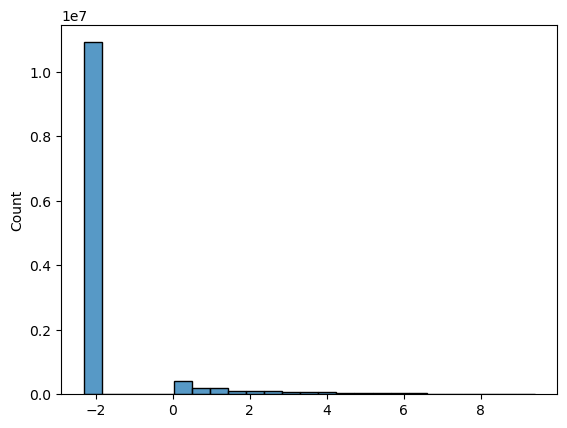

In [276]:
seaborn.histplot(np.log(data.flatten()+0.1))

<Axes: ylabel='Count'>

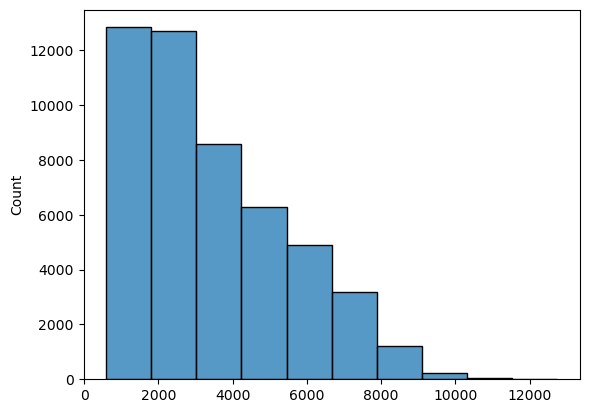

In [277]:
seaborn.histplot(data.sum(1).flatten(),bins=10)

In [278]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [279]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.001}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.JitTrace_ELBO())

# Training loop
num_iterations = 30
losses = []

In [280]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
        #if loss >0.6:
        #    print('EXPLODE KLASLKJASLDKFJALSKDJFALKSDJFLKAJSDFLKAJSDFKLJASLKDFJALKSDJFKLASDJFLKAJSDFLKJASDFLKJASLKDFJASDF')
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]

torch.Size([32, 250])


ValueError: Model and guide shapes disagree at site 'latent': torch.Size([32, 32, 11]) vs torch.Size([32, 11])

In [ ]:
antipode.plotting.plot_loss(losses[5000:])

In [ ]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [ ]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [ ]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

In [ ]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


In [ ]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [ ]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

In [ ]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().log().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Log Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [ ]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)

In [ ]:
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('variable mean')
plt.ylabel('mean |gradient|')